In [1]:
import numpy as np
import matplotlib.pyplot as plt
import LAMINAR
from sklearn.datasets import make_moons, make_circles, make_blobs
import torch
from sklearn.metrics.pairwise import pairwise_distances

In [2]:
colour = {
    'g': np.array([0, 158, 115])/256,
    'b': np.array([0, 114, 178])/256,
    'lb': np.array([86, 180, 233])/256,
    'r': np.array([213, 94, 0])/256,
    'o': np.array([230, 159, 0])/256,
    'y': np.array([240, 228, 66])/256,
    'p': np.array([204, 121, 167])/256,
    }

In [3]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [4]:
def moons():
    X, y = make_moons(n_samples=1000, noise=0.1)
    X = (X-X.mean(axis=0))/X.std(axis=0)

    data = torch.tensor(X, dtype=torch.float32)
    labels = torch.tensor(y, dtype=torch.float32)

    # shuffle data and labels
    idx = torch.randperm(data.size(0))
    data = data[idx]
    labels = labels[idx]
    return data.to(device), labels.to(device)

def circles():
    X, y = make_circles(n_samples=1000, noise=0.05, factor=0.65)
    X = (X-X.mean(axis=0))/X.std(axis=0)

    data = torch.tensor(X, dtype=torch.float32)
    labels = torch.tensor(y, dtype=torch.float32)

    idx = torch.randperm(data.size(0))
    data = data[idx]
    labels = labels[idx]
    return data.to(device), labels.to(device)

def streched_gaussians():
    X, Labels = make_blobs(n_samples=1000, random_state=170)
    transformation = [[0.6, -0.6], [-0.4, 0.8]]
    X_aniso = np.dot(X, transformation)

    data = (X_aniso - X_aniso.mean(axis=0)) / X_aniso.std(axis=0)
    data = torch.tensor(data, dtype=torch.float32)
    labels = torch.tensor(Labels, dtype=torch.float32)

    idx = torch.randperm(data.size(0))
    data = data[idx]
    labels = labels[idx]
    return data.to(device), labels.to(device)

def combined_structure():
    data, labels = make_moons(n_samples=500, noise=0.1)

    # take the upper moons as data1
    data1 = data[labels == 0]
    data1[:, 0] = data1[:, 0] * 2

    # lower moon as data2
    data2 = data[labels == 1]

    # move and scale lower moon
    data2 = (data2 + np.array([-1, 1.5])) * -3

    # gaussian distribution at 0 0
    data3 = np.random.normal(loc=np.array([0, -1]), scale=0.65, size=(500, 2))

    labels = np.zeros(1000, dtype=int)
    labels[250:] = 1
    labels[500:] = 2
    
    data = np.vstack([data1, data2, data3])

    # standardize
    data = (data - data.mean(axis=0)) / data.std(axis=0)

    data = torch.tensor(data, dtype=torch.float32)
    labels = torch.tensor(labels, dtype=torch.float32)

    idx = torch.randperm(data.size(0))
    data = data[idx]
    labels = labels[idx]

    return data.to(device), labels.to(device)

def four_gaussians():
    n = 1000
    n_per_gaussian = n // 4

    g1 = np.random.normal(size=(n_per_gaussian, 2))
    g2 = np.random.normal(size=(n_per_gaussian, 2))
    g3 = np.random.normal(size=(n_per_gaussian, 2))
    g4 = np.random.normal(size=(n_per_gaussian, 2))

    g1[:, 0] -= 1.5
    g1[:, 1] -= 0.25

    g1 *= 0.75

    g2[:, 0] += 3
    g2[:, 1] += 3

    g2 *= 0.5

    g3[:, 0] += 3
    g3[:, 1] -= 1.5

    g3 *= 0.25

    g4[:, 0] -= 1.5
    g4[:, 1] += 3

    g4[:, 0] *= 0.15

    data = np.vstack([g1, g2, g3, g4])
    data = (data - data.mean(axis=0)) / data.std(axis=0)

    labels = np.zeros(n, dtype=int)
    labels[n_per_gaussian:] = 1
    labels[2*n_per_gaussian:] = 2
    labels[3*n_per_gaussian:] = 3

    data = torch.tensor(data, dtype=torch.float32)
    labels = torch.tensor(labels, dtype=torch.float32)

    idx = torch.randperm(data.size(0))
    data = data[idx]
    labels = labels[idx]

    return data.to(device), labels.to(device)
    

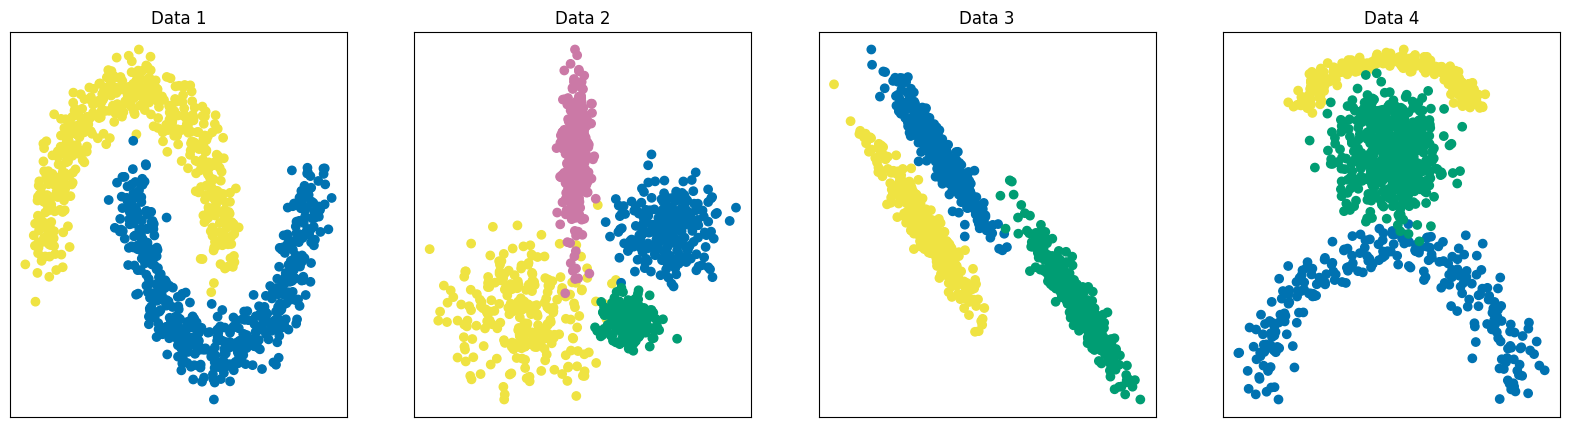

In [5]:
data1 = moons()
data2 = four_gaussians()
data3 = streched_gaussians()
data4 = combined_structure()

fig, axs = plt.subplots(1, 4, figsize=(20, 5))

for i, (data, labels) in enumerate([data1, data2, data3, data4]):
    axs[i].scatter(data[labels == 0, 0], data[labels == 0, 1], c=[colour['y'] for _ in range(data[labels == 0].shape[0])])
    axs[i].scatter(data[labels == 1, 0], data[labels == 1, 1], c=[colour['b'] for _ in range(data[labels == 1].shape[0])])
    axs[i].scatter(data[labels == 2, 0], data[labels == 2, 1], c=[colour['g'] for _ in range(data[labels == 2].shape[0])])
    axs[i].scatter(data[labels == 3, 0], data[labels == 3, 1], c=[colour['p'] for _ in range(data[labels == 3].shape[0])])
    axs[i].scatter(data[labels == 4, 0], data[labels == 4, 1], c=[colour['lb'] for _ in range(data[labels == 4].shape[0])])
    axs[i].set_title(f"Data {i+1}")
    axs[i].set_xticks([])
    axs[i].set_yticks([])

plt.show()


In [6]:
LAM1 = LAMINAR.LAMINAR(data1[0], drop_freq=9999, epochs=1500)

Iteration 0 | Train Loss: 1325.80419921875 | Validation Loss: 2235.834716796875
Iteration 99 | Train Loss: 271.0395812988281 | Validation Loss: 265.53472900390625
Iteration 199 | Train Loss: 213.0423126220703 | Validation Loss: 211.96446228027344
Iteration 299 | Train Loss: 192.6101531982422 | Validation Loss: 192.82411193847656
Iteration 399 | Train Loss: 180.43051147460938 | Validation Loss: 187.6957550048828
Iteration 499 | Train Loss: 177.53012084960938 | Validation Loss: 186.39126586914062
Iteration 599 | Train Loss: 179.90213012695312 | Validation Loss: 186.4021759033203
Iteration 699 | Train Loss: 176.62762451171875 | Validation Loss: 186.9155731201172
Iteration 799 | Train Loss: 177.08619689941406 | Validation Loss: 188.50424194335938
Iteration 899 | Train Loss: 177.32901000976562 | Validation Loss: 189.6851348876953
Iteration 999 | Train Loss: 174.56353759765625 | Validation Loss: 186.8912353515625
Early stopping at iteration 999


In [6]:
LAM2 = LAMINAR.LAMINAR(data2[0], drop_freq=9999, epochs=1500)

Iteration 0 | Train Loss: 1226.1239013671875 | Validation Loss: 1955.30517578125
Iteration 99 | Train Loss: 261.51251220703125 | Validation Loss: 277.30889892578125
Iteration 199 | Train Loss: 201.8084259033203 | Validation Loss: 241.64830017089844
Iteration 299 | Train Loss: 193.5858154296875 | Validation Loss: 211.42979431152344
Iteration 399 | Train Loss: 190.6392364501953 | Validation Loss: 209.94036865234375
Iteration 499 | Train Loss: 188.3828125 | Validation Loss: 209.0340576171875
Iteration 599 | Train Loss: 186.7511444091797 | Validation Loss: 207.5774383544922
Iteration 699 | Train Loss: 186.353515625 | Validation Loss: 208.2808380126953
Iteration 799 | Train Loss: 186.03001403808594 | Validation Loss: 205.15594482421875
Iteration 899 | Train Loss: 187.427490234375 | Validation Loss: 205.82693481445312
Iteration 999 | Train Loss: 183.5818328857422 | Validation Loss: 204.5491485595703
Iteration 1099 | Train Loss: 184.4393768310547 | Validation Loss: 205.51441955566406
Iteratio

In [8]:
LAM3 = LAMINAR.LAMINAR(data3[0], drop_freq=9999, epochs=1500)

Iteration 0 | Train Loss: 1429.429931640625 | Validation Loss: 2101.915771484375
Iteration 99 | Train Loss: 172.73419189453125 | Validation Loss: 172.47457885742188
Iteration 199 | Train Loss: 165.8124542236328 | Validation Loss: 169.51168823242188
Iteration 299 | Train Loss: 139.83639526367188 | Validation Loss: 137.27369689941406
Iteration 399 | Train Loss: 128.35031127929688 | Validation Loss: 127.71629333496094
Iteration 499 | Train Loss: 127.6656723022461 | Validation Loss: 124.51953125
Iteration 599 | Train Loss: 125.44784545898438 | Validation Loss: 125.808349609375
Iteration 699 | Train Loss: 124.0601577758789 | Validation Loss: 122.53024291992188
Iteration 799 | Train Loss: 124.2772216796875 | Validation Loss: 121.44097900390625
Iteration 899 | Train Loss: 124.23825073242188 | Validation Loss: 122.69233703613281
Iteration 999 | Train Loss: 127.94086456298828 | Validation Loss: 124.76908111572266
Iteration 1099 | Train Loss: 123.7314453125 | Validation Loss: 122.98489379882812


In [9]:
LAM4 = LAMINAR.LAMINAR(data4[0], drop_freq=9999, epochs=1500)

Iteration 0 | Train Loss: 1140.317626953125 | Validation Loss: 2005.253662109375
Iteration 99 | Train Loss: 257.19561767578125 | Validation Loss: 271.5460510253906
Iteration 199 | Train Loss: 210.54623413085938 | Validation Loss: 216.9400177001953
Iteration 299 | Train Loss: 201.48692321777344 | Validation Loss: 202.59292602539062
Iteration 399 | Train Loss: 192.9911346435547 | Validation Loss: 202.9476776123047
Iteration 499 | Train Loss: 191.89163208007812 | Validation Loss: 200.84803771972656
Iteration 599 | Train Loss: 191.65403747558594 | Validation Loss: 202.02186584472656
Iteration 699 | Train Loss: 192.99798583984375 | Validation Loss: 205.18902587890625
Iteration 799 | Train Loss: 193.2045440673828 | Validation Loss: 203.56813049316406
Iteration 899 | Train Loss: 191.5658721923828 | Validation Loss: 201.06463623046875
Iteration 999 | Train Loss: 189.60739135742188 | Validation Loss: 201.90863037109375
Early stopping at iteration 999


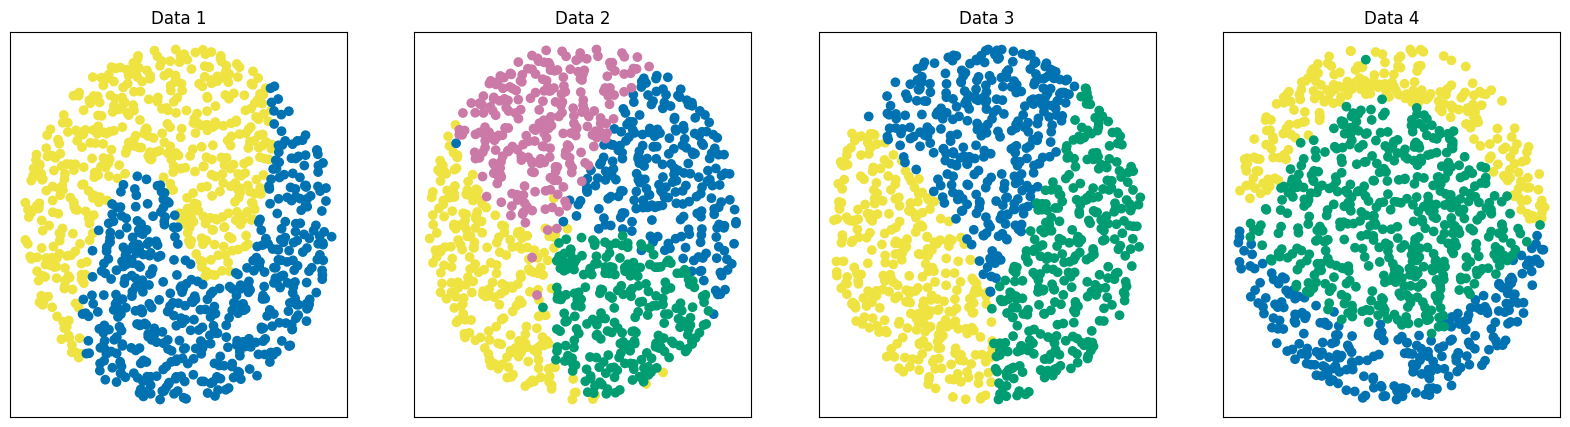

In [10]:
data1_pushed = LAM1.X_pushed
data2_pushed = LAM2.X_pushed
data3_pushed = LAM3.X_pushed
data4_pushed = LAM4.X_pushed

fig, axs = plt.subplots(1, 4, figsize=(20, 5))

for i, data_pushed, data in zip([0, 1, 2, 3], [data1_pushed, data2_pushed, data3_pushed, data4_pushed], [data1, data2, data3, data4]):
    axs[i].scatter(data_pushed[data[1] == 0, 0], data_pushed[data[1] == 0, 1], c=[colour['y'] for _ in range(data_pushed[data[1] == 0].shape[0])])
    axs[i].scatter(data_pushed[data[1] == 1, 0], data_pushed[data[1] == 1, 1], c=[colour['b'] for _ in range(data_pushed[data[1] == 1].shape[0])])
    axs[i].scatter(data_pushed[data[1] == 2, 0], data_pushed[data[1] == 2, 1], c=[colour['g'] for _ in range(data_pushed[data[1] == 2].shape[0])])
    axs[i].scatter(data_pushed[data[1] == 3, 0], data_pushed[data[1] == 3, 1], c=[colour['p'] for _ in range(data_pushed[data[1] == 3].shape[0])])
    axs[i].scatter(data_pushed[data[1] == 4, 0], data_pushed[data[1] == 4, 1], c=[colour['lb'] for _ in range(data_pushed[data[1] == 4].shape[0])])
    axs[i].set_title(f"Data {i+1}")
    axs[i].set_xticks([])
    axs[i].set_yticks([])

plt.show()

In [7]:
def k_medoids(X, k, max_iter=100):
    """
    K-Medoids clustering algorithm
    :param X: numpy array of shape (n_samples, n_features)
    :param k: Number of clusters
    :param max_iter: Maximum number of iterations
    :return: (medoids, labels)
    """
    n_samples = X.shape[0]
    
    # Randomly initialize k medoids
    medoid_indices = np.random.choice(n_samples, k, replace=False)
    medoids = X[medoid_indices]
    
    for _ in range(max_iter):
        # Compute distance matrix
        distances = pairwise_distances(X, medoids, metric='manhattan')
        
        # Assign labels based on closest medoid
        labels = np.argmin(distances, axis=1)
        
        # Update medoids
        new_medoids = np.copy(medoids)
        for i in range(k):
            cluster_points = X[labels == i]
            if len(cluster_points) == 0:
                continue
            
            # Compute cost for each cluster point as new medoid
            costs = np.sum(pairwise_distances(cluster_points, cluster_points, metric='manhattan'), axis=1)
            new_medoids[i] = cluster_points[np.argmin(costs)]
        
        # Check for convergence
        # Fix: np.all() does not support axis=None for object arrays, use (new_medoids == medoids).all()
        if (new_medoids == medoids).all():
            break
        medoids = new_medoids
    
    return medoids, labels


def k_medoids_LAM(data, k, LAM, max_iter=100):
    # initialize medoids
    medoids = data[torch.randperm(data.size(0))[:k]]
    n = data.shape[0]
    
    for i in range(max_iter):
        # calculate distances
        idx, dists = LAM.query(medoids)
        
        dists = dists[idx < n].reshape(k, n)

        idx, sort_idx = torch.sort(idx, dim=1)
        for _ in range(k):
            dists[_] = dists[_, sort_idx[_]]

        # assign medoids
        _, assignments = dists.min(dim=0)
        new_medoids = torch.clone(medoids)
        # update medoids
        for j in range(k):
            
            # get indices of all points in the cluster j
            cluster_points = idx[j, assignments == j]

            if len(cluster_points) == 0:
                continue

            # get distance matrix of LAM
            distance_matrix, _ = LAMINAR.utils.dijkstra.dijkstra(LAM.graph, cluster_points.cpu().numpy(), cluster_points.cpu().numpy())
            
            distance_matrix = np.array(distance_matrix, dtype=np.float32)

            # only take rows and columns where cluster_points is True
            #distance_matrix = distance_matrix[cluster_points][:, cluster_points]

            distance_matrix = torch.tensor(distance_matrix, dtype=torch.float32)
            # sum over all columns
            sum = torch.sum(distance_matrix, dim=1)

            #print(sum)
            # minimum of the sum is the new medoid centre
            new_medoids[j] = data[cluster_points][sum.argmin()]

            #print('Lowest value in iteration', i, 'is', sum.min(), 'at', new_medoids[j])
            medoids = new_medoids
    return medoids, assignments

In [8]:
# do clustering for all datasets with euclidean metric

medoids1_euc, labels1_euc = k_medoids(data1[0], 2)
medoids2_euc, labels2_euc = k_medoids(data2[0], 4)
medoids3_euc, labels3_euc = k_medoids(data3[0], 3)
medoids4_euc, labels4_euc = k_medoids(data4[0], 3)

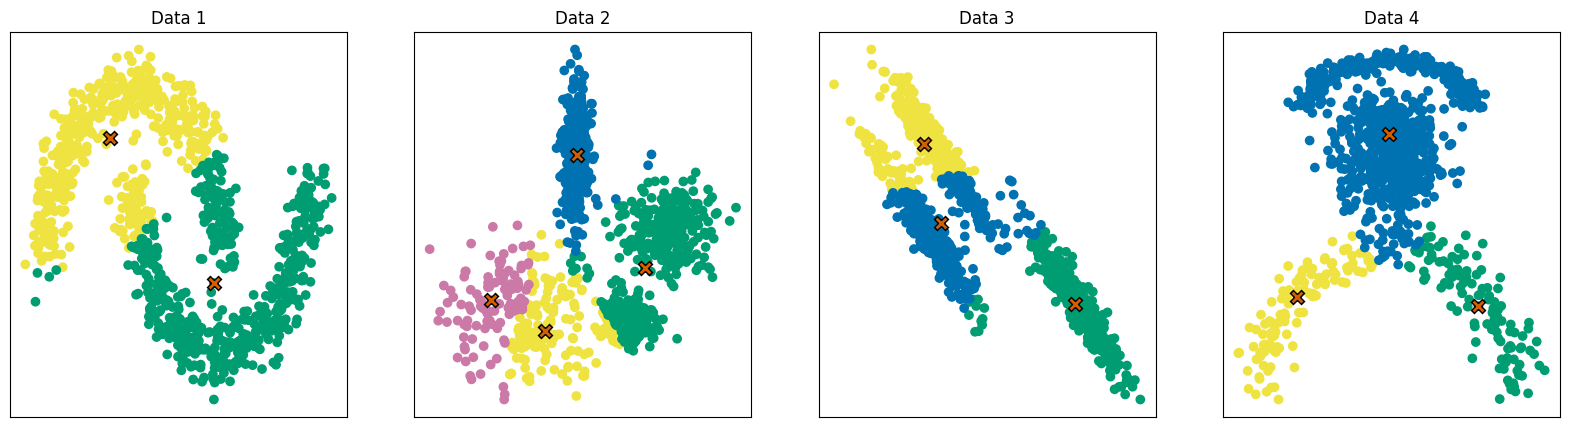

In [9]:
# plot clustering with euclidean
fig, axs = plt.subplots(1, 4, figsize=(20, 5))

for i, (data, labels, medoids) in enumerate([(data1[0], labels1_euc, medoids1_euc), (data2[0], labels2_euc, medoids2_euc), (data3[0], labels3_euc, medoids3_euc), (data4[0], labels4_euc, medoids4_euc)]):
    axs[i].scatter(data[labels == 0, 0], data[labels == 0, 1], c=[colour['y'] for _ in range(data[labels == 0].shape[0])])
    axs[i].scatter(data[labels == 1, 0], data[labels == 1, 1], c=[colour['g'] for _ in range(data[labels == 1].shape[0])])
    axs[i].scatter(data[labels == 2, 0], data[labels == 2, 1], c=[colour['b'] for _ in range(data[labels == 2].shape[0])])
    axs[i].scatter(data[labels == 3, 0], data[labels == 3, 1], c=[colour['p'] for _ in range(data[labels == 3].shape[0])])
    axs[i].scatter(data[labels == 4, 0], data[labels == 4, 1], c=[colour['lb'] for _ in range(data[labels == 4].shape[0])])

    axs[i].scatter(medoids[:, 0], medoids[:, 1], c='black', marker='x', s=75, linewidths=4)
    axs[i].scatter(medoids[:, 0], medoids[:, 1], c=[colour['r']], marker='x', s=50, linewidths=2)
    axs[i].set_title(f"Data {i+1}")
    axs[i].set_xticks([])
    axs[i].set_yticks([])

plt.show()

In [23]:
# same with LAM

medoids1_lam, labels1_lam = k_medoids_LAM(data1[0], 2, LAM1)

In [23]:
medoids2_lam, labels2_lam = k_medoids_LAM(data2[0], 4, LAM2)

In [25]:
medoids3_lam, labels3_lam = k_medoids_LAM(data3[0], 3, LAM3)

In [34]:
medoids4_lam, labels4_lam = k_medoids_LAM(data4[0], 3, LAM4)

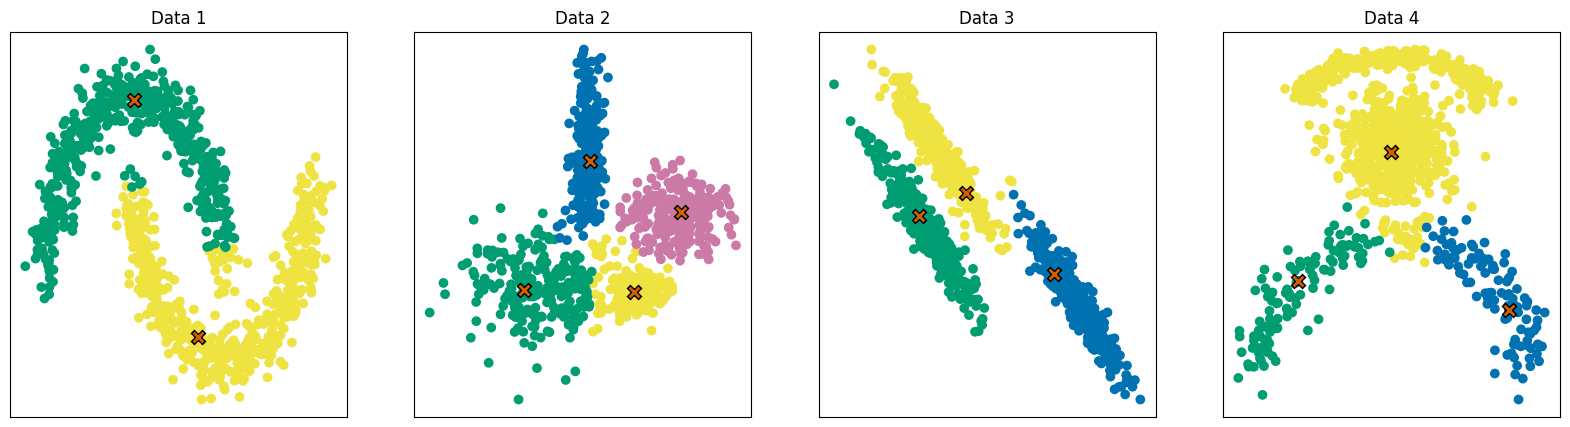

In [35]:
# plot clustering with LAM
fig, axs = plt.subplots(1, 4, figsize=(20, 5))

for i, (data, labels, medoids) in enumerate([(data1[0], labels1_lam, medoids1_lam), (data2[0], labels2_lam, medoids2_lam), (data3[0], labels3_lam, medoids3_lam), (data4[0], labels4_lam, medoids4_lam)]):
    axs[i].scatter(data[labels == 0, 0], data[labels == 0, 1], c=[colour['y'] for _ in range(data[labels == 0].shape[0])])
    axs[i].scatter(data[labels == 1, 0], data[labels == 1, 1], c=[colour['g'] for _ in range(data[labels == 1].shape[0])])
    axs[i].scatter(data[labels == 2, 0], data[labels == 2, 1], c=[colour['b'] for _ in range(data[labels == 2].shape[0])])
    axs[i].scatter(data[labels == 3, 0], data[labels == 3, 1], c=[colour['p'] for _ in range(data[labels == 3].shape[0])])
    axs[i].scatter(data[labels == 4, 0], data[labels == 4, 1], c=[colour['lb'] for _ in range(data[labels == 4].shape[0])])

    axs[i].scatter(medoids[:, 0], medoids[:, 1], c='black', marker='x', s=75, linewidths=4)
    axs[i].scatter(medoids[:, 0], medoids[:, 1], c=[colour['r']], marker='x', s=50, linewidths=2)
    axs[i].set_title(f"Data {i+1}")
    axs[i].set_xticks([])
    axs[i].set_yticks([])

In [11]:
from itertools import permutations

def calculate_min_error_rate(ground_truth, predicted):
    # Convert tensors to numpy arrays if needed
    if isinstance(ground_truth, torch.Tensor):
        ground_truth = ground_truth.numpy()
    if isinstance(predicted, torch.Tensor):
        predicted = predicted.numpy()

    gt_labels = np.unique(ground_truth)
    pred_labels = np.unique(predicted)

    min_error_rate = float('inf')

    for perm in permutations(pred_labels):
        # Only map as many predicted labels as there are ground truth labels
        label_mapping = {pred_label: gt_label for pred_label, gt_label in zip(perm, gt_labels)}

        # For predicted labels not in mapping, assign a dummy label (e.g., -1)
        mapped_predicted = np.array([label_mapping.get(pred_label, -1) for pred_label in predicted])

        error_rate = np.mean(mapped_predicted != ground_truth)

        if error_rate < min_error_rate:
            min_error_rate = error_rate

    return min_error_rate

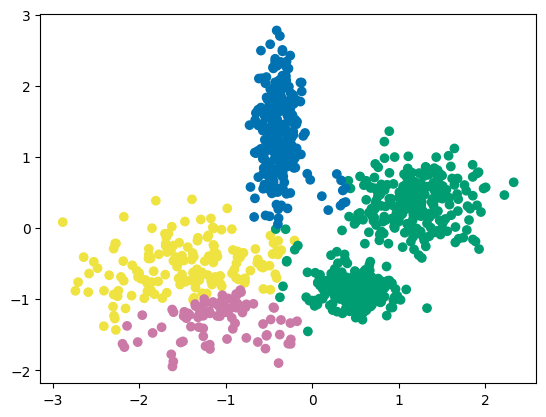

In [24]:
# plot data2 with labels2_lam
plt.scatter(data2[0][labels2_lam == 0, 0], data2[0][labels2_lam == 0, 1], c=[colour['y'] for _ in range(data2[0][labels2_lam == 0].shape[0])])
plt.scatter(data2[0][labels2_lam == 1, 0], data2[0][labels2_lam == 1, 1], c=[colour['g'] for _ in range(data2[0][labels2_lam == 1].shape[0])])
plt.scatter(data2[0][labels2_lam == 2, 0], data2[0][labels2_lam == 2, 1], c=[colour['b'] for _ in range(data2[0][labels2_lam == 2].shape[0])])
plt.scatter(data2[0][labels2_lam == 3, 0], data2[0][labels2_lam == 3, 1], c=[colour['p'] for _ in range(data2[0][labels2_lam == 3].shape[0])])


In [25]:
calculate_min_error_rate(data2[1], labels2_lam)

0.359

In [19]:
calculate_min_error_rate(data2[1], labels2_euc)

0.378

In [36]:
def jaccard(points1, points2):
    n = len(points1)
    m = len(points2)
    intersection = len(set(points1.numpy()).intersection(set(points2.numpy())))

    if m + n - intersection == 0:
        return np.round(0.0, 2)
    else:
        return np.round(intersection / (n + m - intersection), 2)

In [37]:
# calculate jaccard index for all datasets

for i, d, euc_lab, lam_lab in zip([0, 1, 2, 3], [data1, data2, data3, data4], [labels1_euc, labels2_euc, labels3_euc, labels4_euc], [labels1_lam, labels2_lam, labels3_lam, labels4_lam]):
    print('Data ', i+1)
    print('\n')
    
    # get indices of the points with certain labels
    gt_idx_1 = torch.where(d[1] == 0)[0]
    gt_idx_2 = torch.where(d[1] == 1)[0]
    gt_idx_3 = torch.where(d[1] == 2)[0]
    gt_idx_4 = torch.where(d[1] == 3)[0]

    # get indices of the points with certain labels
    euclidean_idx_1 = torch.where(torch.tensor(euc_lab) == 0)[0]
    euclidean_idx_2 = torch.where(torch.tensor(euc_lab) == 1)[0]
    euclidean_idx_3 = torch.where(torch.tensor(euc_lab) == 2)[0]
    euclidean_idx_4 = torch.where(torch.tensor(euc_lab) == 3)[0]

    # sma for lam
    lam_idx_1 = torch.where(lam_lab == 0)[0]
    lam_idx_2 = torch.where(lam_lab == 1)[0]
    lam_idx_3 = torch.where(lam_lab == 2)[0]
    lam_idx_4 = torch.where(lam_lab == 3)[0]

    print('Euclidean')
    print(jaccard(gt_idx_1, euclidean_idx_1), jaccard(gt_idx_2, euclidean_idx_1), jaccard(gt_idx_3, euclidean_idx_1), jaccard(gt_idx_4, euclidean_idx_1))
    print(jaccard(gt_idx_1, euclidean_idx_2), jaccard(gt_idx_2, euclidean_idx_2), jaccard(gt_idx_3, euclidean_idx_2), jaccard(gt_idx_4, euclidean_idx_2))
    print(jaccard(gt_idx_1, euclidean_idx_3), jaccard(gt_idx_2, euclidean_idx_3), jaccard(gt_idx_3, euclidean_idx_3), jaccard(gt_idx_4, euclidean_idx_3))   
    print(jaccard(gt_idx_1, euclidean_idx_4), jaccard(gt_idx_2, euclidean_idx_4), jaccard(gt_idx_3, euclidean_idx_4), jaccard(gt_idx_4, euclidean_idx_4))

    print('\n')

    print('LAM')
    print(jaccard(gt_idx_1, lam_idx_1), jaccard(gt_idx_2, lam_idx_1), jaccard(gt_idx_3, lam_idx_1), jaccard(gt_idx_4, lam_idx_1))
    print(jaccard(gt_idx_1, lam_idx_2), jaccard(gt_idx_2, lam_idx_2), jaccard(gt_idx_3, lam_idx_2), jaccard(gt_idx_4, lam_idx_2))
    print(jaccard(gt_idx_1, lam_idx_3), jaccard(gt_idx_2, lam_idx_3), jaccard(gt_idx_3, lam_idx_3), jaccard(gt_idx_4, lam_idx_3))
    print(jaccard(gt_idx_1, lam_idx_4), jaccard(gt_idx_2, lam_idx_4), jaccard(gt_idx_3, lam_idx_4), jaccard(gt_idx_4, lam_idx_4))

    print('\n')



    

Data  1


Euclidean
0.11 0.72 0.0 0.0
0.7 0.07 0.0 0.0
0.0 0.0 0.0 0.0
0.0 0.0 0.0 0.0


LAM
0.03 0.94 0.0 0.0
0.94 0.01 0.0 0.0
0.0 0.0 0.0 0.0
0.0 0.0 0.0 0.0


Data  2


Euclidean
0.01 0.0 0.0 0.97
0.0 0.93 0.0 0.0
0.05 0.03 0.85 0.0
0.87 0.0 0.0 0.0


LAM
0.04 0.01 0.89 0.0
0.88 0.0 0.0 0.0
0.01 0.0 0.0 0.96
0.0 0.96 0.0 0.0


Data  3


Euclidean
0.11 0.58 0.0 0.0
0.57 0.17 0.02 0.0
0.02 0.0 0.92 0.0
0.0 0.0 0.0 0.0


LAM
0.0 0.99 0.01 0.0
1.0 0.0 0.0 0.0
0.0 0.0 0.99 0.0
0.0 0.0 0.0 0.0


Data  4


Euclidean
0.63 0.0 0.19 0.0
0.0 0.24 0.55 0.0
0.0 0.42 0.0 0.0
0.0 0.0 0.0 0.0


LAM
0.32 0.03 0.64 0.0
0.0 0.44 0.0 0.0
0.0 0.42 0.0 0.0
0.0 0.0 0.0 0.0


